We are trying to create a flow using a function from a 2D Gaussian function to a bimodal gaussian. (function used f = z + a*(tanh(z))) It is more detailed below. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

Importing all the requirements:

torch: tensor math + autodiff

nn: define learnable models

optim: optimizers

matplotlib: visualize results

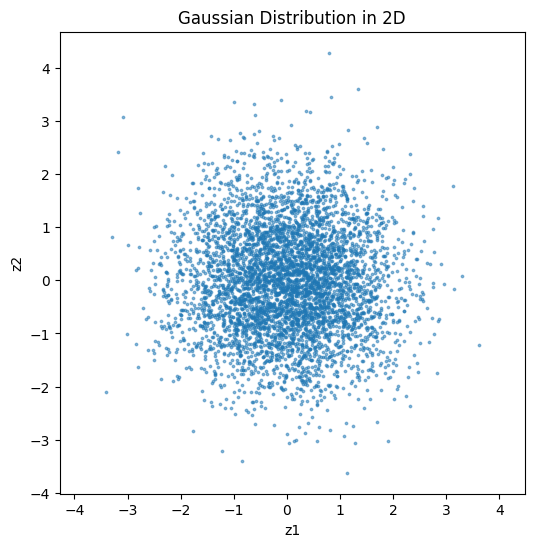

In [12]:
base_dist = torch.distributions.MultivariateNormal(
    torch.zeros(2),
    torch.eye(2)
)
#Plot the graph
p = base_dist.sample((5000,))
plt.figure(figsize=(6,6))
plt.scatter(p[:,0].numpy(), p[:,1].numpy(), s=3, alpha=0.5)
plt.title("Gaussian Distribution in 2D")
plt.xlabel("z1")
plt.ylabel("z2")
plt.axis("equal")
plt.show()

base distribution is 2D Gaussian
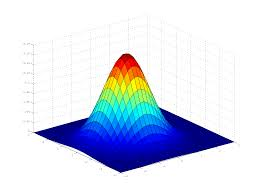

In [6]:
class BananaFlow(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0)) #Learnable parameters initialized to 1.0
        self.b = nn.Parameter(torch.tensor(1.0))

    def forward(self, z):
        x1 = z[:, 0] 
        x2 = z[:, 1] + self.a * torch.tanh(self.b * z[:, 0])
        x = torch.stack([x1, x2], dim=1)

        # Jacobian determinant
        jacobian = torch.tensor(1.0, device=z.device, dtype=z.dtype)   # It is just that the jacobian is 1.0 but a tensor now; triangular Jacobian
        log_det = torch.log(torch.abs(jacobian))

        return x, log_det

    def inverse(self, x):
        z1 = x[:, 0]
        z2 = x[:, 1] - self.a * torch.tanh(self.b * z[:, 0])
        z = torch.stack([z1, z2], dim=1)

        jacobian = 1.0
        log_det = torch.log(torch.abs(jacobian))

        return z, log_det



We’ll use a planar flow–style transformation: z1 - dimension 1 of gaussian 2D, z2 - dimension 2 of gaussian 2D
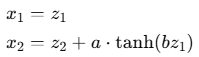

We have two parameters here: a and b. 
The data is split into 2 x1 and x2 (this is basically to get coupling flow). One set of data remains unchanged and the other set of data use
parameters based on other dataset. This is done to easily calculate the differential of the transformation or the jacobian.
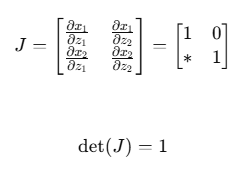
Question: Why do we do log(determinant)? 

Inverse is a simple function based on the forward feed. ( I am sorry if you find it hard to read the page below. 

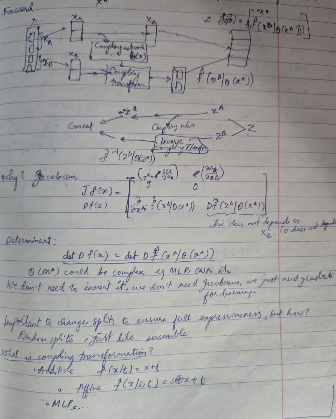

In [7]:
flow = BananaFlow()

with torch.no_grad():
    z = base_dist.sample((5000,))
    x, _ = flow.forward(z) 


x2 = z[:, 1] + self.a * torch.tanh(self.b * z[:, 0]) Here put a = 1 and b = 1,
**x2 = z2 + tanh(z1)**

Work to be done : **Plot  for a single  point and demonstrate**

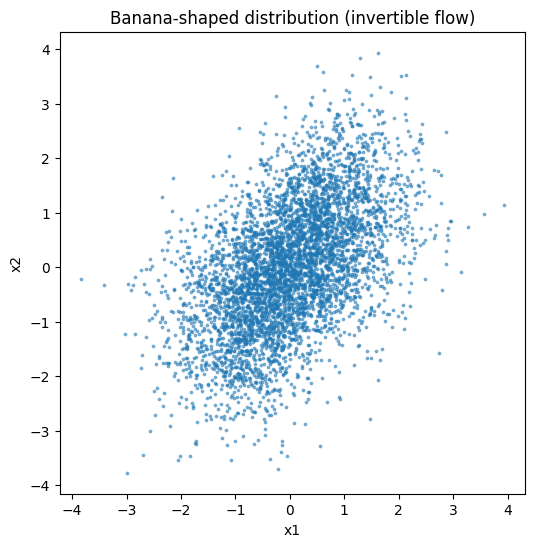

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(x[:,0].numpy(), x[:,1].numpy(), s=3, alpha=0.5)
plt.title("Banana-shaped distribution (invertible flow)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

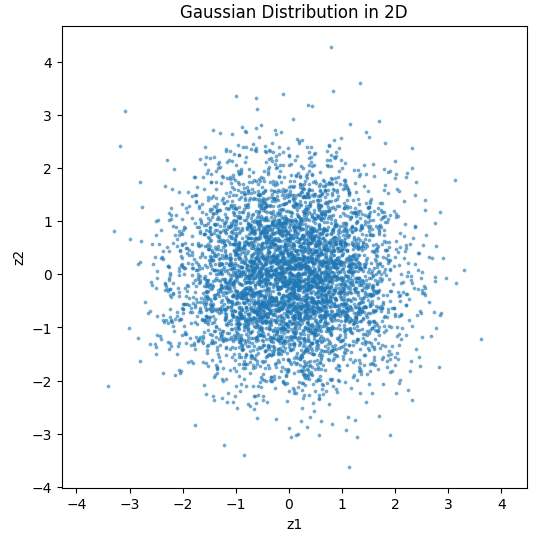  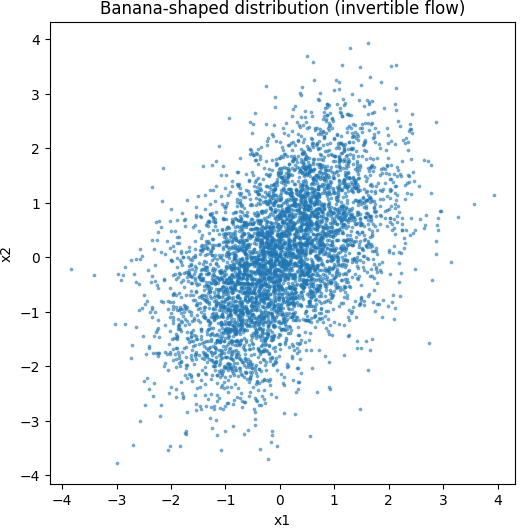

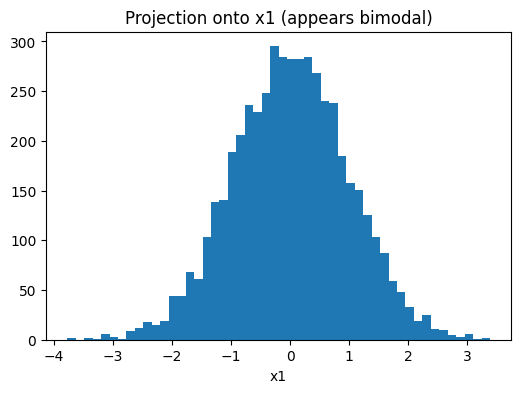

In [19]:
plt.figure(figsize=(6,4))
plt.hist(z[:,1].numpy(), bins=50)
plt.title("Projection onto x1 (appears bimodal)")
plt.xlabel("x1")
plt.show()

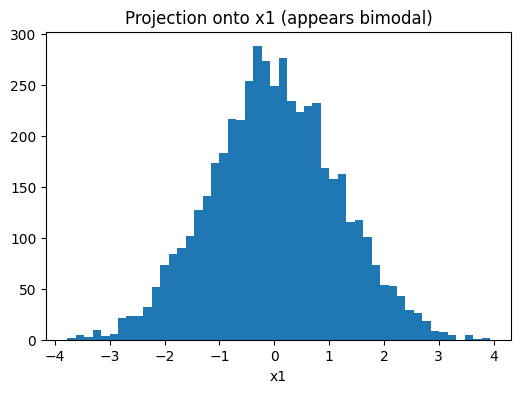

In [18]:
plt.figure(figsize=(6,4))
plt.hist(x[:,1].numpy(), bins=50)
plt.title("Projection onto x1 (appears bimodal)")
plt.xlabel("x1")
plt.show()

What is the outcome?
We applied only one coupling layer, i.e., one function, we didnt even invert. we just tried to use the function to map a gaussian to approimation of skewed version bimodal. 
What we missed, just a simple function cannot map it, we need multiple of such invertible functions.
What can normalizing flows do?
They can shift, scale, shear, rotate and twist the input data. They cannot split or tear the data. This is also disadvantage of Normalizing flows which is made better in flow matching. 

In the next version, we will still try to get data to bimodal. Never give up!!!